# Bosch CNC Edge Intelligence

## Notebook 01: Dataset Exploration

### Objectives

- Understand the Bosch CNC dataset
- Explore HDF5 file structure
- Inspect available sensors
- Identify labels
- Visualize raw signals
- Prepare for feature engineering

from google.colab import drive
drive.mount('/content/drive')

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Imports**

In [2]:
from pathlib import Path

import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

**Configure Paths**

In [3]:
from pathlib import Path

# Root directory
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Bosch-CNC-Edge-Intelligence"
)

# Dataset directory
DATASET_DIR = Path(
    "/content/drive/MyDrive/Bosch-CNC-Edge-Intelligence/datasets/data"
)

print(PROJECT_ROOT)
print(DATASET_DIR)

/content/drive/MyDrive/Bosch-CNC-Edge-Intelligence
/content/drive/MyDrive/Bosch-CNC-Edge-Intelligence/datasets/data


In [4]:
print("Project Exists :", PROJECT_ROOT.exists())
print("Dataset Exists :", DATASET_DIR.exists())

Project Exists : True
Dataset Exists : True


In [5]:
for root, dirs, files in os.walk(DATASET_DIR):

    print("="*70)

    print(root)

    print("Folders :", dirs)

    print("Files :", files)

/content/drive/MyDrive/Bosch-CNC-Edge-Intelligence/datasets/data
Folders : ['M02', 'M03', 'M01']
Files : []
/content/drive/MyDrive/Bosch-CNC-Edge-Intelligence/datasets/data/M02
Folders : ['OP08', 'OP10', 'OP14', 'OP12', 'OP07', 'OP09', 'OP05', 'OP06', 'OP02', 'OP00', 'OP01', 'OP04', 'OP03', 'OP13', 'OP11']
Files : []
/content/drive/MyDrive/Bosch-CNC-Edge-Intelligence/datasets/data/M02/OP08
Folders : ['bad', 'good']
Files : []
/content/drive/MyDrive/Bosch-CNC-Edge-Intelligence/datasets/data/M02/OP08/bad
Folders : []
Files : ['M02_Aug_2019_OP08_000.h5', 'M02_Aug_2021_OP08_000.h5', 'M02_Feb_2019_OP08_001.h5', 'M02_Feb_2019_OP08_000.h5']
/content/drive/MyDrive/Bosch-CNC-Edge-Intelligence/datasets/data/M02/OP08/good
Folders : []
Files : ['M02_Feb_2021_OP08_001.h5', 'M02_Aug_2020_OP08_003.h5', 'M02_Feb_2020_OP08_003.h5', 'M02_Aug_2019_OP08_001.h5', 'M02_Feb_2021_OP08_002.h5', 'M02_Aug_2019_OP08_005.h5', 'M02_Feb_2021_OP08_000.h5', 'M02_Feb_2020_OP08_001.h5', 'M02_Aug_2019_OP08_016.h5', 'M02_

# 1. Dataset Overview

## Research Questions

- What is the Bosch CNC Machining Dataset?
- Who created it?
- Why was it collected?
- What industrial problem does it address?
- Why is it suitable for Edge AI research?

Metadata Extraction

In [6]:
import pandas as pd

records = []

for machine in DATASET_DIR.iterdir():

    if not machine.is_dir():
        continue

    for operation in machine.iterdir():

        if not operation.is_dir():
            continue

        for label in operation.iterdir():

            if not label.is_dir():
                continue

            for file in label.glob("*.h5"):

                records.append({
                    "Machine": machine.name,
                    "Operation": operation.name,
                    "Label": label.name,
                    "Filename": file.name,
                    "Path": str(file)
                })

metadata = pd.DataFrame(records)

metadata.head()

,Machine,Operation,Label,Filename,Path
0,M02,OP08,bad,M02_Aug_2019_OP08_000.h5,/content/drive/MyDrive/Bosch-CNC-Edge-Intellig...
1,M02,OP08,bad,M02_Aug_2021_OP08_000.h5,/content/drive/MyDrive/Bosch-CNC-Edge-Intellig...
2,M02,OP08,bad,M02_Feb_2019_OP08_001.h5,/content/drive/MyDrive/Bosch-CNC-Edge-Intellig...
3,M02,OP08,bad,M02_Feb_2019_OP08_000.h5,/content/drive/MyDrive/Bosch-CNC-Edge-Intellig...
4,M02,OP08,good,M02_Feb_2021_OP08_001.h5,/content/drive/MyDrive/Bosch-CNC-Edge-Intellig...


**Dataset Statistics**


In [9]:
#Total Samples
print("Total Files :", len(metadata))






Total Files : 1702


,count
Label,
good,1632
bad,70


In [10]:
#Number of Machines
metadata["Machine"].value_counts()


,count
Machine,
M02,644
M03,539
M01,519


In [12]:
#Operations
metadata["Operation"].value_counts()

,count
Operation,
OP07,158
OP02,152
OP01,143
OP13,142
OP12,123
OP05,120
OP08,119
OP10,119
OP09,114


In [13]:
#Labels
metadata["Label"].value_counts()

,count
Label,
good,1632
bad,70


In [14]:
summary = pd.DataFrame({
    "Metric":[
        "Total Files",
        "Machines",
        "Operations",
        "Labels"
    ],
    "Value":[
        len(metadata),
        metadata["Machine"].nunique(),
        metadata["Operation"].nunique(),
        metadata["Label"].nunique()
    ]
})

summary

,Metric,Value
0,Total Files,1702
1,Machines,3
2,Operations,15
3,Labels,2


**Data** **Visualization**

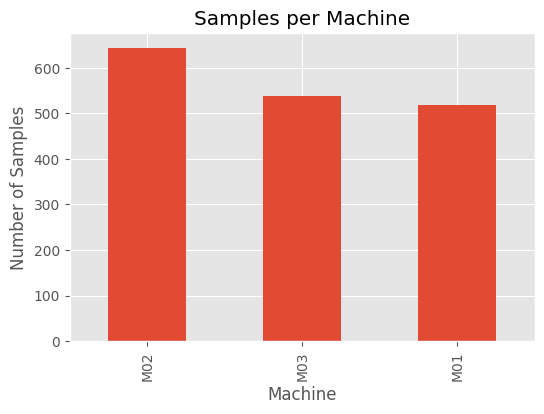

In [20]:
import matplotlib.pyplot as plt

metadata["Machine"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Samples per Machine")
plt.xlabel("Machine")
plt.ylabel("Number of Samples")

plt.show()

**Operation Distribution**

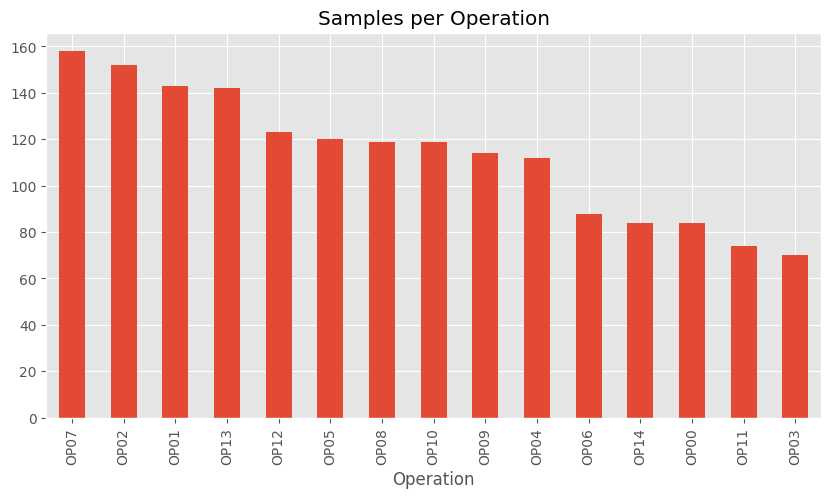

In [21]:
metadata["Operation"].value_counts().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Samples per Operation")

plt.show()

# **Label Distribution**

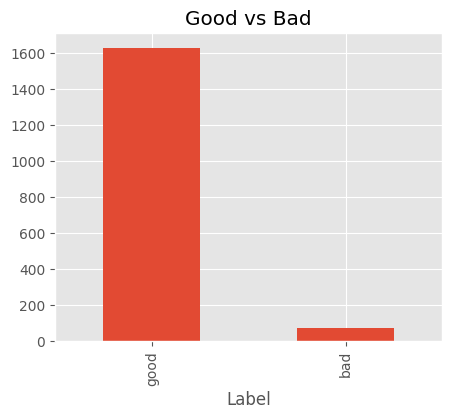

In [22]:
metadata["Label"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Good vs Bad")

plt.show()

**Explore HDF5 Structure**

In [26]:
import h5py

sample = metadata.iloc[0]["Path"]

with h5py.File(sample,"r") as f:

    print("Keys")

    print(list(f.keys()))
with h5py.File(sample,"r") as f:

    def print_structure(name,obj):

        print(name)

    f.visititems(print_structure)

Keys
['vibration_data']
vibration_data


**Sensor Analysis**
After identifying the sensor datasets, answer:

How many sensors are present?
What are their names?
What is the sampling frequency?
What is the signal length?
What data type is used?
Are all sensors synchronized?

Open one HDF5 file

In [42]:
sample = metadata.iloc[0]["Path"]

In [41]:
import h5py

with h5py.File(sample, "r") as f:
    print("Top-Level Keys:")
    print(list(f.keys()))

Top-Level Keys:
['vibration_data']


In [40]:
#Print the complete hierarchy
with h5py.File(sample, "r") as f:

    def print_structure(name, obj):
        print(name, type(obj))

    f.visititems(print_structure)

vibration_data <class 'h5py._hl.dataset.Dataset'>


In [39]:
with h5py.File(sample, "r") as f:

    def explore(name, obj):

        if isinstance(obj, h5py.Dataset):

            print("="*60)
            print("Dataset :", name)
            print("Shape   :", obj.shape)
            print("Dtype   :", obj.dtype)

    f.visititems(explore)

Dataset : vibration_data
Shape   : (59184, 3)
Dtype   : float64


In [44]:
with h5py.File(sample, "r") as f:
    print("File Attributes")
    print(dict(f.attrs))

    print("\nDataset Attributes")
    print(dict(f["vibration_data"].attrs))

File Attributes
{}

Dataset Attributes
{}


In [45]:
with h5py.File(sample, "r") as f:
    signal = f["vibration_data"][:]

print(signal.shape)

print(signal[:5])

(59184, 3)
[[  302.  -956. -1380.]
 [ -154.   267. -1159.]
 [  228.   165.   265.]
 [  273.   618. -1895.]
 [    7.   823. -1046.]]


In [47]:
channel_1 = signal[:, 0]
channel_2 = signal[:, 1]
channel_3 = signal[:, 2]
print(channel_1.shape)
print(channel_2.shape)
print(channel_3.shape)

(59184,)
(59184,)
(59184,)


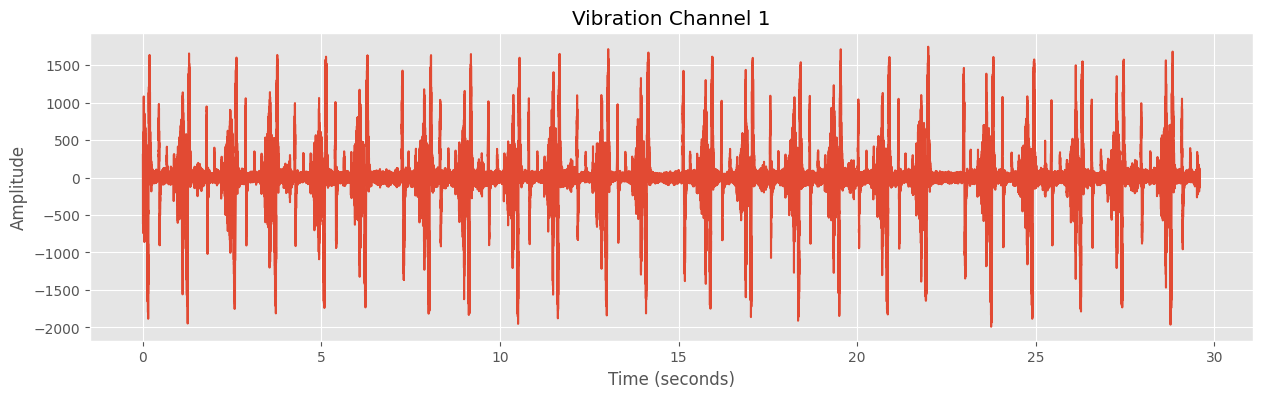

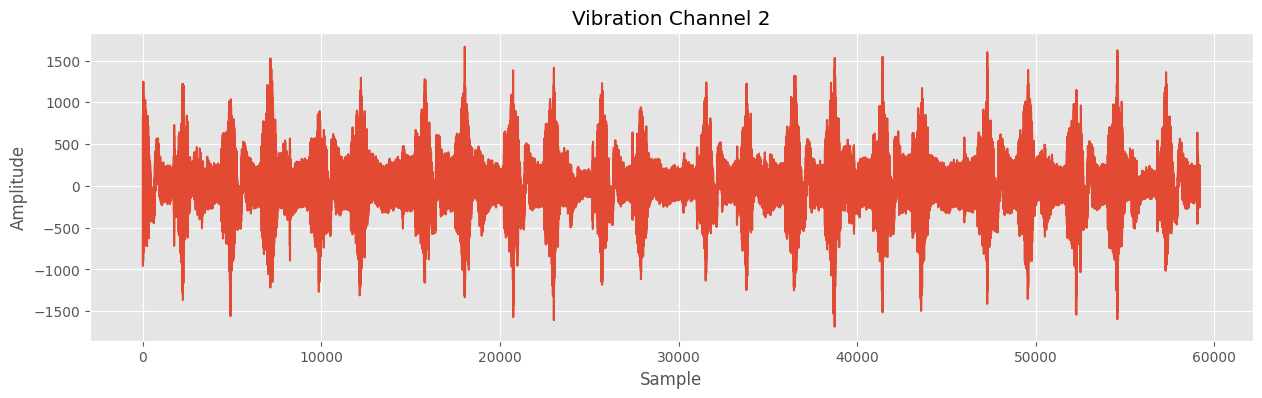

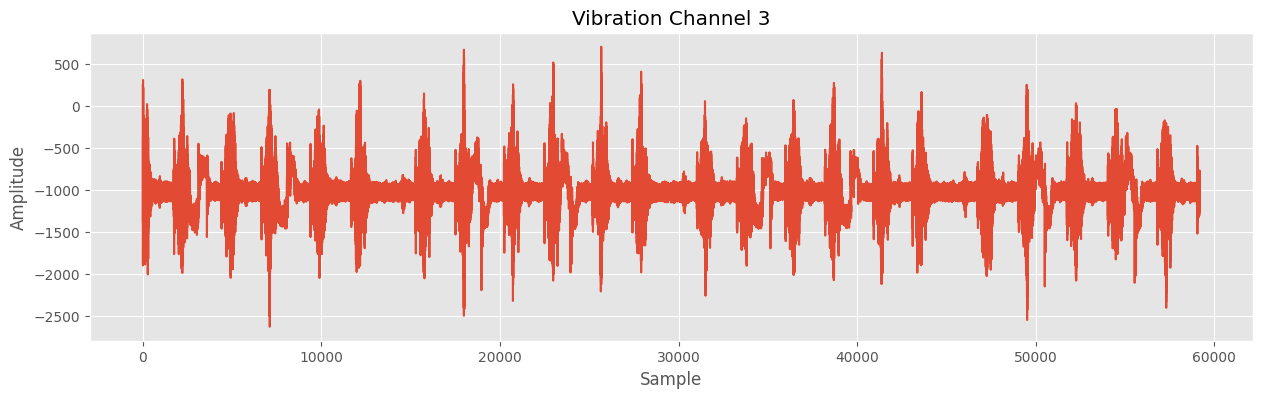

In [59]:
import matplotlib.pyplot as plt

# ------------------------
# Channel 1
# ------------------------
import numpy as np
import matplotlib.pyplot as plt

fs = 2000   # Sampling frequency = 2 kHz

time = np.arange(len(channel_1)) / fs

plt.figure(figsize=(15,4))

plt.plot(time, channel_1)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Vibration Channel 1")

plt.show()


# ------------------------
# Channel 2
# ------------------------
plt.figure(figsize=(15,4))

plt.plot(channel_2)

plt.title("Vibration Channel 2")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()


# ------------------------
# Channel 3
# ------------------------
plt.figure(figsize=(15,4))

plt.plot(channel_3)

plt.title("Vibration Channel 3")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

In [49]:
import pandas as pd

df = pd.DataFrame({
    "Channel 1": channel_1,
    "Channel 2": channel_2,
    "Channel 3": channel_3
})

df.describe()

,Channel 1,Channel 2,Channel 3
count,59184.000000,59184.000000,59184.000000
mean,1.163102,3.974165,-1031.727122
std,354.099952,281.771126,219.611330
min,-1991.000000,-1686.000000,-2625.000000
25%,-48.000000,-156.000000,-1108.000000
50%,7.000000,3.000000,-1046.000000
75%,52.000000,160.000000,-942.000000
max,1745.000000,1665.000000,710.000000


In [50]:
df.isnull().sum()

,0
Channel 1,0
Channel 2,0
Channel 3,0
